# Garbage Severity Classifier

## Setup & Installation

In [28]:
# !pip install torch torchvision matplotlib scikit-learn seaborn Pillow tqdm

In [29]:
import json
import os
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Download TACO Dataset

TACO (Trash Annotations in Context) uses COCO-style annotations.  
Each image has bounding-box/mask annotations for individual trash instances.  
We use the **instance count per image** to derive a severity label.

```
git clone https://github.com/pedropro/TACO.git
cd TACO
pip install -r requirements.txt
python download.py
```

After running the above, the structure will be:
```
TACO/
  data/
    annotations.json
    batch_1/
      000001.jpg ...
    batch_2/
      ...
```

Set `TACO_ROOT` below to wherever you cloned the repo.

In [30]:
# Get len of TACO images, annotations, and categories
TACO_ROOT = Path("./TACO")
ANNOTATIONS_FILE = TACO_ROOT / "data" / "annotations.json"

assert ANNOTATIONS_FILE.exists(), (
    f"Annotations not found at {ANNOTATIONS_FILE}. "
    "Clone TACO and run `python download.py` first."
)

with open(ANNOTATIONS_FILE) as f:
    coco = json.load(f)

print(f"Images:      {len(coco['images'])}")
print(f"Annotations: {len(coco['annotations'])}")
print(f"Categories:  {len(coco['categories'])}")

Images:      1500
Annotations: 4784
Categories:  60


## Parse Annotations & Assign Severity Labels

Instead of raw instance count, we use **total annotated area as a fraction of image area** — a single large sofa is more severe than 3 cigarette butts.

| Area ratio | Label   |
|------------|---------|
| 0          | clean   |
| < 3%       | low     |
| 3–15%      | medium  |
| ≥ 15%      | high    |

Thresholds are tunable — a distribution plot is printed to help calibrate.

Total usable images: 1500
  clean   :    0 images
  low     : 1012 images
  medium  :  344 images
  high    :  144 images


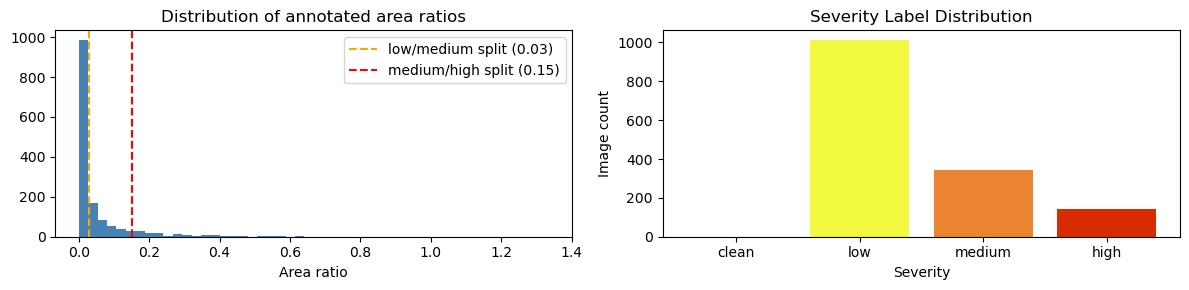

In [31]:
SEVERITY_LABELS = ["clean", "low", "medium", "high"]
LABEL_TO_IDX = {label: i for i, label in enumerate(SEVERITY_LABELS)}


def area_ratio_to_severity(ratio: float) -> str:
    if ratio == 0:
        return "clean"
    elif ratio < 0.03:
        return "low"
    elif ratio < 0.15:
        return "medium"
    else:
        return "high"


# Build image size lookup
image_sizes = {img["id"]: (img["width"], img["height"]) for img in coco["images"]}

# Sum annotated area per image
image_areas: dict[int, float] = {}
for ann in coco["annotations"]:
    img_id = ann["image_id"]
    w, h = image_sizes.get(img_id, (1, 1))
    image_areas[img_id] = image_areas.get(img_id, 0.0) + ann.get("area", 0.0) / (w * h)

# Build records
records = []
for img in coco["images"]:
    img_id = img["id"]
    ratio = image_areas.get(img_id, 0.0)
    severity = area_ratio_to_severity(ratio)
    file_path = TACO_ROOT / "data" / img["file_name"]
    if file_path.exists():
        records.append({
            "image_id": img_id,
            "file_path": str(file_path),
            "area_ratio": ratio,
            "severity": severity,
            "label": LABEL_TO_IDX[severity],
        })

print(f"Total usable images: {len(records)}")
dist = Counter(r["severity"] for r in records)
for label in SEVERITY_LABELS:
    print(f"  {label:8s}: {dist[label]:4d} images")

# Distribution of area ratios (helps tune thresholds)
ratios = [r["area_ratio"] for r in records if r["area_ratio"] > 0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.hist(ratios, bins=50, color="steelblue")
ax1.axvline(0.03, color="orange", linestyle="--", label="low/medium split (0.03)")
ax1.axvline(0.15, color="red",    linestyle="--", label="medium/high split (0.15)")
ax1.set_xlabel("Area ratio")
ax1.set_title("Distribution of annotated area ratios")
ax1.legend()

ax2.bar(SEVERITY_LABELS, [dist[l] for l in SEVERITY_LABELS],
        color=["#31a222", "#f3f940", "#ea8430", "#d82b00"])
ax2.set_title("Severity Label Distribution")
ax2.set_xlabel("Severity")
ax2.set_ylabel("Image count")
plt.tight_layout()
plt.show()

## Dataset Class & Splits

In [32]:
class TACOSeverityDataset(Dataset):
    def __init__(self, records: list[dict], transform=None):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        image = Image.open(rec["file_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, rec["label"]


# 70 / 15 / 15 split, stratified by severity label
def stratified_split(records, train_frac=0.70, val_frac=0.15, seed=SEED):
    rng = random.Random(seed)
    by_label = {}
    for r in records:
        by_label.setdefault(r["label"], []).append(r)

    train, val, test = [], [], []
    for label_records in by_label.values():
        rng.shuffle(label_records)
        n = len(label_records)
        n_train = int(n * train_frac)
        n_val = int(n * val_frac)
        train += label_records[:n_train]
        val += label_records[n_train:n_train + n_val]
        test += label_records[n_train + n_val:]
    return train, val, test


train_records, val_records, test_records = stratified_split(records)
print(f"Train: {len(train_records)}  Val: {len(val_records)}  Test: {len(test_records)}")

Train: 1048  Val: 223  Test: 229


## Transforms & Data Loaders

Training uses standard ImageNet augmentation. Val/test use only resize + normalize.

In [33]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = TACOSeverityDataset(train_records, transform=train_transform)
val_ds   = TACOSeverityDataset(val_records,   transform=eval_transform)
test_ds  = TACOSeverityDataset(test_records,  transform=eval_transform)

# Weighted sampler to handle class imbalance
label_counts = Counter(r["label"] for r in train_records)
weights = [1.0 / label_counts[r["label"]] for r in train_records]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=0, pin_memory=True)

print(f"Batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

Batches — train: 33  val: 7  test: 8


## Model

Fine-tune a pretrained **EfficientNet-B3** (stronger than ResNet-18, ~12M params vs 11M but significantly more accurate).  
Dropout increased to 0.5. Backbone frozen for first phase, then fully unfrozen.

In [34]:
NUM_CLASSES = len(SEVERITY_LABELS)

model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

# Replace classifier head (EfficientNet-B3 has 1536 features)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(1536, NUM_CLASSES),
)

model = model.to(DEVICE)


def set_backbone_frozen(model: nn.Module, frozen: bool):
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = not frozen


# Start with backbone frozen — only train the head
set_backbone_frozen(model, frozen=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\elyas/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:03<00:00, 15.3MB/s]


Trainable params: 6,148 / 10,702,380


## Training

In [35]:
EPOCHS_FROZEN   = 5
EPOCHS_UNFROZEN = 15   # more epochs — better regularization means less overfitting
LR_HEAD     = 1e-3
LR_FINETUNE = 1e-4
MIXUP_ALPHA = 0.4

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


def mixup_batch(images, labels, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam


def run_epoch(model, loader, optimizer, training: bool):
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
                images, labels_a, labels_b, lam = mixup_batch(images, labels)
                outputs = model(images)
                loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
                loss.backward()
                optimizer.step()
                correct += (outputs.argmax(1) == labels_a).sum().item()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                correct += (outputs.argmax(1) == labels).sum().item()
            total_loss += loss.item() * images.size(0)
            total += images.size(0)
    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}


def train_phase(model, epochs, lr, phase_name):
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, training=True)
        va_loss, va_acc = run_epoch(model, val_loader,   optimizer, training=False)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"[{phase_name}] Epoch {epoch:02d}/{epochs}  "
              f"loss {tr_loss:.4f}/{va_loss:.4f}  "
              f"acc {tr_acc:.3f}/{va_acc:.3f}")

    model.load_state_dict(best_weights)
    print(f"  → Best val acc: {best_val_acc:.3f}")
    return model


# Phase 1: head only
print("=== Phase 1: train head (backbone frozen) ===")
model = train_phase(model, EPOCHS_FROZEN, LR_HEAD, "frozen")

# Phase 2: full fine-tune
print("\n=== Phase 2: full fine-tune ===")
set_backbone_frozen(model, frozen=False)
model = train_phase(model, EPOCHS_UNFROZEN, LR_FINETUNE, "finetune")

=== Phase 1: train head (backbone frozen) ===
[frozen] Epoch 01/5  loss 1.1604/1.1359  acc 0.403/0.507
[frozen] Epoch 02/5  loss 1.0419/1.0421  acc 0.541/0.583
[frozen] Epoch 03/5  loss 1.0188/0.9863  acc 0.506/0.623
[frozen] Epoch 04/5  loss 1.0017/0.9841  acc 0.523/0.614
[frozen] Epoch 05/5  loss 1.0037/0.9794  acc 0.496/0.619
  → Best val acc: 0.623

=== Phase 2: full fine-tune ===
[finetune] Epoch 01/15  loss 0.9380/0.9009  acc 0.469/0.655
[finetune] Epoch 02/15  loss 0.9293/0.8674  acc 0.565/0.668
[finetune] Epoch 03/15  loss 0.9302/0.8117  acc 0.515/0.731
[finetune] Epoch 04/15  loss 0.8847/0.8222  acc 0.524/0.713
[finetune] Epoch 05/15  loss 0.8444/0.7816  acc 0.496/0.753
[finetune] Epoch 06/15  loss 0.8621/0.7734  acc 0.530/0.758
[finetune] Epoch 07/15  loss 0.7869/0.7819  acc 0.582/0.735
[finetune] Epoch 08/15  loss 0.7998/0.7600  acc 0.588/0.758
[finetune] Epoch 09/15  loss 0.8032/0.7847  acc 0.638/0.735
[finetune] Epoch 10/15  loss 0.8258/0.7498  acc 0.614/0.780
[finetune] E

## Training Curves

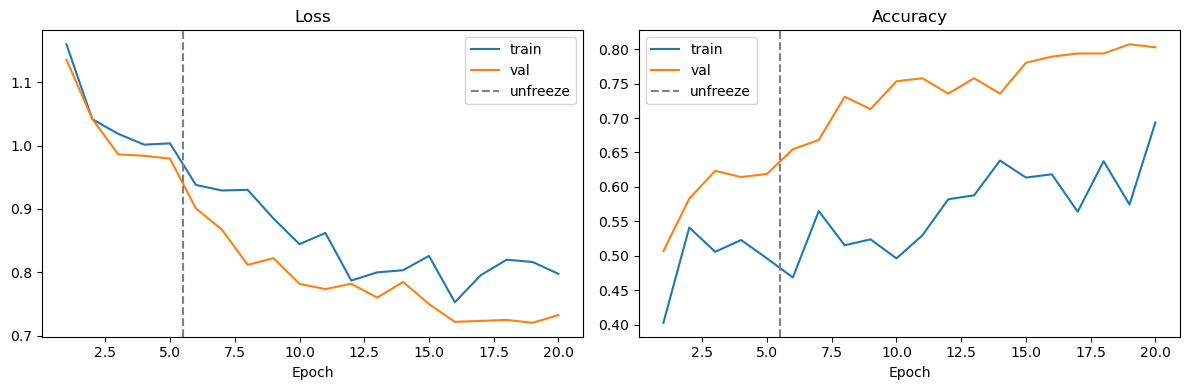

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_range, history["train_loss"], label="train")
ax1.plot(epochs_range, history["val_loss"],   label="val")
ax1.axvline(EPOCHS_FROZEN + 0.5, color="gray", linestyle="--", label="unfreeze")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs_range, history["train_acc"], label="train")
ax2.plot(epochs_range, history["val_acc"],   label="val")
ax2.axvline(EPOCHS_FROZEN + 0.5, color="gray", linestyle="--", label="unfreeze")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluation on Test Set

Evaluating: 100%|██████████| 8/8 [00:33<00:00,  4.24s/it]

              precision    recall  f1-score   support

       clean       0.00      0.00      0.00         0
         low       0.95      0.79      0.86       153
      medium       0.55      0.79      0.65        53
        high       0.69      0.78      0.73        23

    accuracy                           0.79       229
   macro avg       0.55      0.59      0.56       229
weighted avg       0.83      0.79      0.80       229




c:\Users\elyas\anaconda3\envs\reviv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elyas\anaconda3\envs\reviv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elyas\anaconda3\envs\reviv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

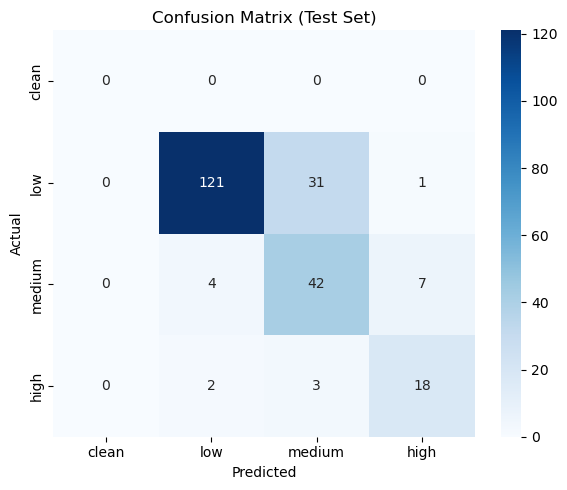

In [37]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

label_idxs = list(range(len(SEVERITY_LABELS)))
print(classification_report(all_labels, all_preds, labels=label_idxs, target_names=SEVERITY_LABELS))

cm = confusion_matrix(all_labels, all_preds, labels=label_idxs)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=SEVERITY_LABELS, yticklabels=SEVERITY_LABELS)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

## Save Model

In [ ]:
SAVE_PATH = Path("./trash_severity_classifier.pt")

torch.save({
    "model_state_dict": model.state_dict(),
    "severity_labels": SEVERITY_LABELS,
    "label_to_idx": LABEL_TO_IDX,
    "img_size": IMG_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
}, SAVE_PATH)

print(f"Model saved to {SAVE_PATH}")


def predict_severity(image_path: str, model: nn.Module, tta_n: int = 8) -> dict:
    """
    Predict severity with Test-Time Augmentation (TTA).
    Runs tta_n augmented passes and averages the softmax scores.
    Set tta_n=1 to disable TTA.
    """
    tta_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    center_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    img = Image.open(image_path).convert("RGB")
    probs = torch.zeros(NUM_CLASSES)

    model.eval()
    with torch.no_grad():
        # Always include one clean center-crop pass
        t = center_transform(img).unsqueeze(0).to(DEVICE)
        probs += torch.softmax(model(t), dim=1).squeeze().cpu()
        # Remaining TTA passes
        for _ in range(tta_n - 1):
            t = tta_transform(img).unsqueeze(0).to(DEVICE)
            probs += torch.softmax(model(t), dim=1).squeeze().cpu()

    probs /= tta_n
    pred_idx = int(probs.argmax())
    return {
        "severity": SEVERITY_LABELS[pred_idx],
        "confidence": round(probs[pred_idx].item(), 4),
        "scores": {label: round(p.item(), 4) for label, p in zip(SEVERITY_LABELS, probs)},
    }


Model saved to trash_severity_classifier.pt


FileNotFoundError: [Errno 2] No such file or directory: 'path/to/your/image.jpg'

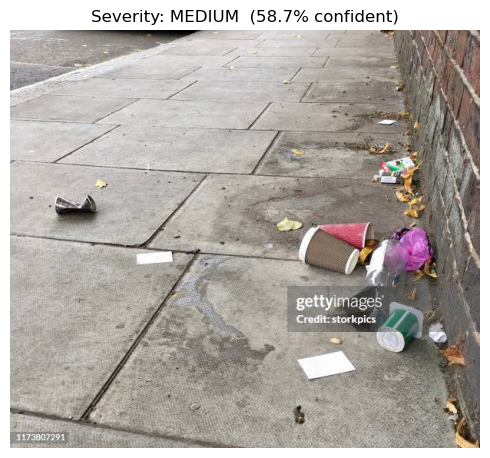

Scores:
  clean    0.0208  
  low      0.3307  █████████████
  medium   0.5871  ███████████████████████
  high     0.0614  ██


In [48]:
IMAGE_PATH = TACO_ROOT / "data" / "new_data" / "minor-garbage-sidewalk.jpg"

result = predict_severity(IMAGE_PATH, model, tta_n=8)

img_display = Image.open(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.axis("off")
plt.title(f"Severity: {result['severity'].upper()}  ({result['confidence']*100:.1f}% confident)")
plt.tight_layout()
plt.show()

print("Scores:")
for label, score in result["scores"].items():
    bar = "█" * int(score * 40)
    print(f"  {label:8s} {score:.4f}  {bar}")

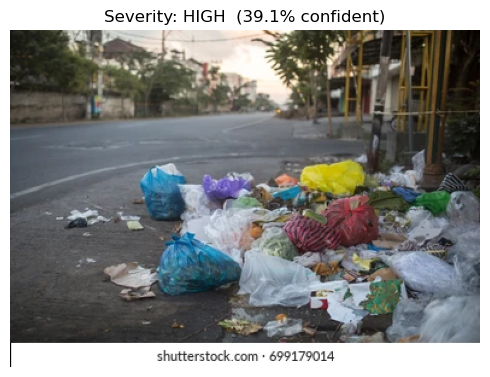

Scores:
  clean    0.0463  █
  low      0.2712  ██████████
  medium   0.2920  ███████████
  high     0.3905  ███████████████


In [40]:
IMAGE_PATH = TACO_ROOT / "data" / "new_data" / "major-garbage-sidewalk.webp"

result = predict_severity(IMAGE_PATH, model, tta_n=8)

img_display = Image.open(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.axis("off")
plt.title(f"Severity: {result['severity'].upper()}  ({result['confidence']*100:.1f}% confident)")
plt.tight_layout()
plt.show()

print("Scores:")
for label, score in result["scores"].items():
    bar = "█" * int(score * 40)
    print(f"  {label:8s} {score:.4f}  {bar}")

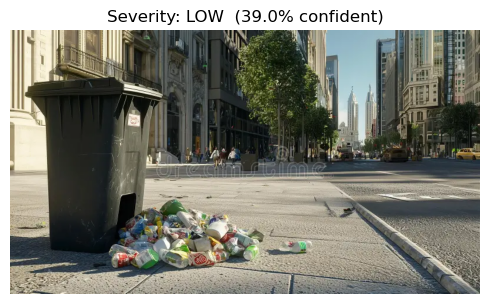

Scores:
  clean    0.0740  ██
  low      0.3901  ███████████████
  medium   0.3188  ████████████
  high     0.2171  ████████


In [42]:
IMAGE_PATH = TACO_ROOT / "data" / "new_data" / "low-1.webp"

result = predict_severity(IMAGE_PATH, model, tta_n=8)

img_display = Image.open(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.axis("off")
plt.title(f"Severity: {result['severity'].upper()}  ({result['confidence']*100:.1f}% confident)")
plt.tight_layout()
plt.show()

print("Scores:")
for label, score in result["scores"].items():
    bar = "█" * int(score * 40)
    print(f"  {label:8s} {score:.4f}  {bar}")

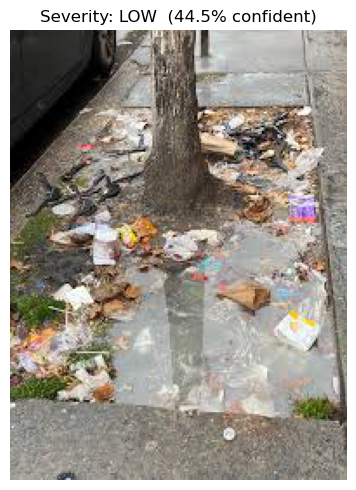

Scores:
  clean    0.0241  
  low      0.4448  █████████████████
  medium   0.4320  █████████████████
  high     0.0991  ███


In [44]:
IMAGE_PATH = TACO_ROOT / "data" / "new_data" / "low-2.jpg"

result = predict_severity(IMAGE_PATH, model, tta_n=8)

img_display = Image.open(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.axis("off")
plt.title(f"Severity: {result['severity'].upper()}  ({result['confidence']*100:.1f}% confident)")
plt.tight_layout()
plt.show()

print("Scores:")
for label, score in result["scores"].items():
    bar = "█" * int(score * 40)
    print(f"  {label:8s} {score:.4f}  {bar}")

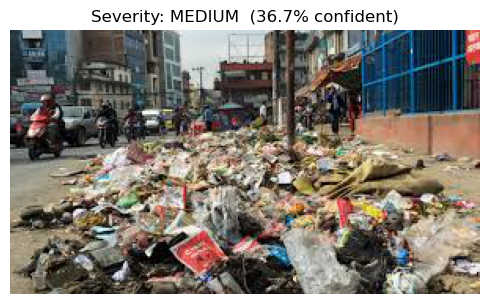

Scores:
  clean    0.0733  ██
  low      0.3216  ████████████
  medium   0.3672  ██████████████
  high     0.2379  █████████


In [45]:
IMAGE_PATH = TACO_ROOT / "data" / "new_data" / "high-1.jpg"

result = predict_severity(IMAGE_PATH, model, tta_n=8)

img_display = Image.open(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.axis("off")
plt.title(f"Severity: {result['severity'].upper()}  ({result['confidence']*100:.1f}% confident)")
plt.tight_layout()
plt.show()

print("Scores:")
for label, score in result["scores"].items():
    bar = "█" * int(score * 40)
    print(f"  {label:8s} {score:.4f}  {bar}")

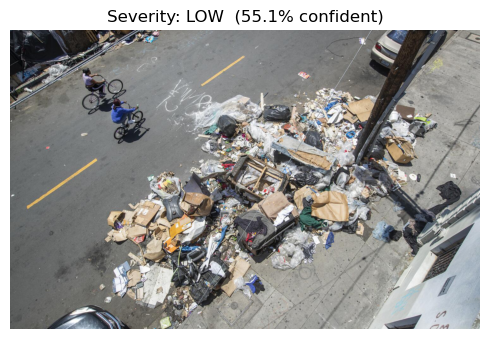

Scores:
  clean    0.0920  ███
  low      0.5514  ██████████████████████
  medium   0.2532  ██████████
  high     0.1034  ████


In [47]:
IMAGE_PATH = TACO_ROOT / "data" / "new_data" / "medium-1.jpg"

result = predict_severity(IMAGE_PATH, model, tta_n=8)

img_display = Image.open(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.axis("off")
plt.title(f"Severity: {result['severity'].upper()}  ({result['confidence']*100:.1f}% confident)")
plt.tight_layout()
plt.show()

print("Scores:")
for label, score in result["scores"].items():
    bar = "█" * int(score * 40)
    print(f"  {label:8s} {score:.4f}  {bar}")

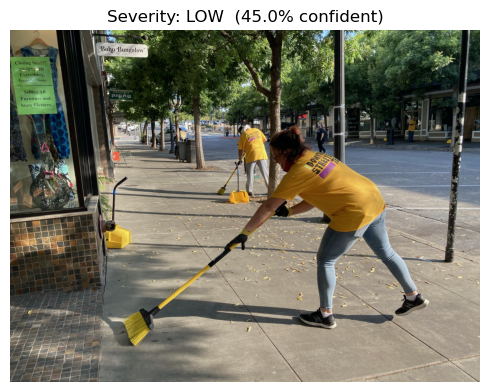

Scores:
  clean    0.0666  ██
  low      0.4499  █████████████████
  medium   0.3496  █████████████
  high     0.1339  █████


In [49]:
IMAGE_PATH = TACO_ROOT / "data" / "new_data" / "clean-1.webp"

result = predict_severity(IMAGE_PATH, model, tta_n=8)

img_display = Image.open(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.axis("off")
plt.title(f"Severity: {result['severity'].upper()}  ({result['confidence']*100:.1f}% confident)")
plt.tight_layout()
plt.show()

print("Scores:")
for label, score in result["scores"].items():
    bar = "█" * int(score * 40)
    print(f"  {label:8s} {score:.4f}  {bar}")